# Three years of a vegetable counter, read end to end

This notebook is the working method behind `reports/analysis_report.txt` — not a
summary of it. It shows the joins, the judgement calls and the two or three places
where the obvious approach gives the wrong answer.

**The data.** A fresh produce counter — vegetables and mushrooms, nothing else —
from 1 July 2020 to 30 June 2023: 878,503 scanned lines across 251 catalogued items
in six categories, with a daily wholesale cost series and a per-item loss rate.

**The question.** What sold, what did not, when the money came in, what went wrong,
and what to do about it.

**The one idea worth carrying through.** Every margin in this business can be
computed two ways — against what the stock cost, or against what the stock cost
*including the portion that spoiled before anyone could buy it*. The gap between
those two numbers is 19% of reported profit, and nothing in a till report will
ever show it.

## 1. Loading and joining

Four files, none of which can answer a margin question alone:

| File | Grain | Carries |
|---|---|---|
| `annex1` | one row per item | name, category |
| `annex2` | one row per scanned line | date, time, quantity, price, sale/return, discount flag |
| `annex3` | one row per item-day | wholesale cost |
| `annex4` | one row per item | loss rate (%) |

`prepare.py` is the only place these are joined, so every number downstream rests
on one set of decisions rather than on whatever each notebook cell felt like doing.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import prepare

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

df = prepare.load()
print(prepare.summarise(df))

rows                 878,503
date range           2020-07-01 to 2023-06-30
trading days         1,085
items sold           246
categories           6
returns              461
discounted lines     47,366
cost imputed (ffill) 0.0% of lines
net revenue          RMB 3,369,766


### The first judgement call: returns

461 rows carry a negative quantity. These are returns, and there are three things
you could do with them: drop them, take their absolute value, or leave them
negative and let them net off.

Leaving them negative is the only one that makes "revenue" mean *money that stayed
in the till*. It matters less here than it would in most datasets — returns are
0.05% of lines — but the habit is worth keeping, because the cost of getting it
wrong scales with a number you do not control.

In [2]:
returns = df[df.is_return]
print(f"return lines      {len(returns):,}")
print(f"value refunded    RMB {-returns.revenue.sum():,.0f}")
print(f"share of revenue  {100 * -returns.revenue.sum() / df.revenue.sum():.3f}%")
returns[['date', 'item_name', 'qty_kg', 'unit_price', 'revenue']].head()

return lines      461
value refunded    RMB 2,257
share of revenue  0.067%


,date,item_name,qty_kg,unit_price,revenue
357,2020-07-01,Broccoli,-0.436,14.0,-6.104
2929,2020-07-03,Wawacai,-1.000,6.9,-6.900
6991,2020-07-07,Wawacai,-1.000,6.5,-6.500
7090,2020-07-07,Wawacai,-1.000,6.9,-6.900
7242,2020-07-07,Wawacai,-1.000,6.9,-6.900


### The second: what a kilo actually costs

`annex3` quotes a wholesale price per item per day. The naive join takes that
price as the cost of goods sold, and it is wrong in a way that flatters the
business.

If an item loses 20% of its stock to spoilage, then selling one kilo means buying
1.25 kg. The cost of a **sold** kilo is therefore `wholesale / (1 - loss_rate)`,
not `wholesale`. Applying the loss rate as a deduction from margin instead of as a
multiplier on cost understates the damage, and understates it worst on exactly the
perishable lines where it matters most.

Both figures are carried through the whole analysis: `profit_raw` (what a till
report shows) and `profit_true` (what the bank sees).

In [3]:
demo = (df.groupby(['item_name'])
          .agg(loss_rate=('loss_rate', 'first'),
               wholesale=('wholesale_price', 'mean'),
               price=('unit_price', 'mean'),
               revenue=('revenue', 'sum'))
          .nlargest(6, 'revenue'))

demo['true_cost']   = demo.wholesale / (1 - demo.loss_rate)
demo['margin_book'] = 100 * (demo.price - demo.wholesale) / demo.price
demo['margin_true'] = 100 * (demo.price - demo.true_cost) / demo.price
demo['points_lost'] = demo.margin_book - demo.margin_true

demo[['loss_rate', 'wholesale', 'true_cost', 'price',
      'margin_book', 'margin_true', 'points_lost']].round(2)

,loss_rate,wholesale,true_cost,price,margin_book,margin_true,points_lost
item_name,,,,,,,
Broccoli,0.09,6.59,7.27,9.90,33.41,26.62,6.80
Net Lotus Root (1),0.06,5.59,5.92,7.95,29.68,25.56,4.12
Xixia Mushroom (1),0.14,11.86,13.76,17.99,34.07,23.49,10.57
Wuhu Green Pepper (1),0.06,5.19,5.50,7.38,29.72,25.47,4.25
Yunnan Shengcai,0.15,5.05,5.96,8.21,38.43,27.35,11.08
Eggplant (2),0.06,5.72,6.09,8.68,34.04,29.77,4.26


### A coverage check worth running before trusting any of it

A cost join is only as good as its coverage. If some sold item-days have no quoted
price, the missing ones get filled — and then a chunk of the margin analysis is
resting on an assumption rather than a measurement.

Here the answer is unusually clean, which is worth confirming rather than hoping for:

In [4]:
wp = prepare.load_wholesale()
quoted = set(zip(wp.date, wp['item_code']))
sold   = set(zip(df.date, df['item_code']))

print(f"sold item-days              {len(sold):,}")
print(f"...without a same-day quote {len(sold - quoted):,}")
print(f"rows with imputed cost      {int(df.cost_imputed.sum()):,}")

sold item-days              46,599
...without a same-day quote 0
rows with imputed cost      0


## 2. The problem with `annex4`

Before any of the loss-adjusted numbers can be trusted, the loss rates themselves
need looking at. Their distribution is not what a set of measurements looks like.

In [5]:
cat = prepare.load_catalogue()
counts = cat.loss_rate_pct.round(2).value_counts().head(6)
print(counts.to_string())
print()
print(f"mean of the whole column: {cat.loss_rate_pct.mean():.4f}")

loss_rate_pct
9.43     85
0.00     22
11.13     7
10.94     5
11.93     3
8.78      2

mean of the whole column: 9.4267


85 of 251 items carry a loss rate of **exactly 9.43%**, which is precisely the mean
of the column. That is not a coincidence and it is not a measurement — it is a
placeholder written over every item nobody measured. A further 22 items sit at
exactly 0.00%, which for fresh vegetables is not credible either.

Those 85 items are about 17% of revenue.

This does not sink the analysis, but it does bound it. The *direction* of every
finding below survives — spoilage is unpriced whichever way you cut it — while any
single per-item figure for a placeholder line is an assumption wearing two decimal
places. Section 5 shows what this looks like on a chart, where it is unmistakable.

In [6]:
placeholder = cat.loss_rate_pct.round(2) == round(cat.loss_rate_pct.mean(), 2)
ph_rev = df[df['item_code'].isin(cat.loc[placeholder, 'item_code'])].revenue.sum()

print(f"items at the placeholder value  {placeholder.sum()} of {len(cat)}")
print(f"items at exactly 0.00%          {(cat.loss_rate_pct == 0).sum()}")
print(f"their share of revenue          {100 * ph_rev / df.revenue.sum():.1f}%")

items at the placeholder value  85 of 251
items at exactly 0.00%          22
their share of revenue          16.7%


## 3. Is the business growing?

This is where a revenue-only report actively misleads. The data begins and ends on
a July–June boundary, so three clean financial years are available with no
part-year stub to explain away.

In [7]:
fy = df.assign(fy=np.where(df.month >= 7, df.year, df.year - 1))
t = fy.groupby('fy').agg(revenue=('revenue', 'sum'),
                         kg=('qty_kg', 'sum'),
                         lines=('revenue', 'size'),
                         days=('date', 'nunique'),
                         profit_true=('profit_true', 'sum'))

for c in ('revenue', 'kg', 'lines'):
    t[c + '_pd'] = t[c] / t.days
t['price_per_kg']    = t.revenue / t.kg
t['kg_per_line']     = t.kg / t.lines
t['margin_true_pct'] = 100 * t.profit_true / t.revenue
t.index = [f"FY{y}/{str(y + 1)[2:]}" for y in t.index]

t[['revenue_pd', 'kg_pd', 'lines_pd', 'price_per_kg',
   'kg_per_line', 'margin_true_pct']].round(2)

,revenue_pd,kg_pd,lines_pd,price_per_kg,kg_per_line,margin_true_pct
FY2020/21,3542.08,451.01,956.65,7.85,0.47,28.33
FY2021/22,2554.17,316.92,676.40,8.06,0.47,28.40
FY2022/23,3224.22,536.03,796.17,6.01,0.67,32.54


In [8]:
first, last = t.iloc[0], t.iloc[-1]
for label, a, b in [('Revenue/day', first.revenue_pd, last.revenue_pd),
                    ('Kilos/day',   first.kg_pd,      last.kg_pd),
                    ('Lines/day',   first.lines_pd,   last.lines_pd),
                    ('Price/kg',    first.price_per_kg, last.price_per_kg),
                    ('Kg per line', first.kg_per_line,  last.kg_per_line)]:
    print(f"{label:<14}{a:9.2f} -> {b:9.2f}   {(b / a - 1) * 100:+6.1f}%")

Revenue/day     3542.08 ->   3224.22     -9.0%
Kilos/day        451.01 ->    536.03    +18.9%
Lines/day        956.65 ->    796.17    -16.8%
Price/kg           7.85 ->      6.01    -23.4%
Kg per line        0.47 ->      0.67    +42.8%


Read those five lines together, because any one alone tells a different story:

* the shop moved **19% more produce** in year three than in year one;
* across **17% fewer scanned lines**;
* so each line got **43% heavier** — fewer, bigger purchases;
* average price per kilo fell **23%**;
* and takings landed **9% down**.

This is not a demand problem — volume grew. Revenue fell because price per kilo
fell faster than volume rose, and margin *percentage* actually improved over the
same period, so the shop is not being squeezed on markup either.

What cannot be settled here is whether "fewer lines" means fewer customers or the
same customers buying vegetables elsewhere. There is no customer ID in these files,
and they cover only the produce counter. Both readings fit, and they call for
opposite responses, so it is worth resolving before acting on it.

One caution on the comparison: FY21/22 is the trough on every measure, so year one
against year three skips over a disrupted middle rather than describing a smooth
trend.

## 4. When the money arrives

Two separate questions that often get merged: *which days*, and *which hours*.

In [9]:
daily = df.groupby('date').agg(revenue=('revenue', 'sum'), lines=('revenue', 'size'))
top10 = daily.nlargest(10, 'revenue')
top10.assign(weekday=top10.index.day_name()).round(0)

,revenue,lines,weekday
date,,,
2021-02-10,28737.0,3747,Wednesday
2021-02-09,18775.0,2501,Tuesday
2023-01-20,18368.0,3177,Friday
2022-01-30,16480.0,2158,Sunday
2022-01-29,14241.0,1859,Saturday
2023-01-19,13105.0,2128,Thursday
2021-02-08,11444.0,1747,Monday
2022-11-19,10121.0,3215,Saturday
2022-01-28,9985.0,1292,Friday


In [10]:
cny = [pd.Timestamp(d) for d in ('2021-02-12', '2022-02-01', '2023-01-22')]
near = sum(any(0 <= (c - d).days <= 7 for c in cny) for d in top10.index)

print(f"top-10 days falling in the week before Chinese New Year: {near}")
print(f"best day vs median day: {top10.revenue.iloc[0] / daily.revenue.median():.1f}x")

top-10 days falling in the week before Chinese New Year: 8
best day vs median day: 10.4x


Eight of the ten best days in three years fall in the week before Chinese New Year.
The two exceptions are 19 and 21 November 2022 — which sit immediately before a
four-day unplanned closure, so they are stockpiling ahead of a shutdown rather than
ordinary trade.

That is a genuinely useful planning fact: the largest revenue event of the year is
known to the calendar, lasts about four days, and repeats in all three years here.

In [11]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
d = df.groupby('dow_name').agg(revenue=('revenue', 'sum'),
                               lines=('revenue', 'size'),
                               days=('date', 'nunique')).reindex(order)
d['rev_per_day']   = d.revenue / d.days
d['lines_per_day'] = d.lines / d.days
d[['rev_per_day', 'lines_per_day']].round(0)

,rev_per_day,lines_per_day
dow_name,,
Monday,2743.0,729.0
Tuesday,2685.0,703.0
Wednesday,2810.0,723.0
Thursday,2667.0,699.0
Friday,3058.0,786.0
Saturday,3956.0,1032.0
Sunday,3825.0,998.0


In [12]:
days = df.date.nunique()
hr = df.groupby('hour').agg(revenue=('revenue', 'sum'),
                            profit_true=('profit_true', 'sum'),
                            lines=('revenue', 'size'))
hr['rev_per_day'] = hr.revenue / days
hr['margin_pct']  = 100 * hr.profit_true / hr.revenue
hr['pct_of_rev']  = 100 * hr.revenue / hr.revenue.sum()
hr.loc[9:21, ['rev_per_day', 'margin_pct', 'pct_of_rev']].round(2)

,rev_per_day,margin_pct,pct_of_rev
hour,,,
9,259.52,29.73,8.36
10,431.74,30.03,13.90
11,339.24,30.39,10.92
12,177.66,30.53,5.72
13,131.61,30.40,4.24
14,155.90,30.43,5.02
15,227.75,30.27,7.33
16,295.22,30.44,9.51
17,325.12,30.54,10.47


The trading day has **two peaks, not one** — a 09:00–11:00 market run and a
16:00–18:00 after-work rush, split by a midday trough at about a third of peak.

The 21:00 hour is the one to look at twice: 2% of revenue at the thinnest margin of
the day, and the most heavily discounted hour. It is the weakest hour on all three
measures at once.

## 5. Where the money actually leaks

The tempting framing is "which products lose money". On this data that framing
finds almost nothing, and the reason it finds nothing is the interesting part.

In [13]:
# Grain is item_code -- the real key. Two different items can share a name.
it = df.groupby(['item_code', 'item_name', 'category']).agg(
        revenue=('revenue', 'sum'),
        profit_book=('profit_raw', 'sum'),
        profit_true=('profit_true', 'sum'),
        loss_rate=('loss_rate', 'first')).reset_index()

trap = it[(it.profit_book > 0) & (it.profit_true < 0)]
print(f"items that flip from profit to loss once spoilage is paid for: {len(trap)}")
print(f"their combined true loss: RMB {-trap.profit_true.sum():,.0f}")
print()
print(f"total cost of spoilage across the business: "
      f"RMB {(it.profit_book - it.profit_true).sum():,.0f}")

items that flip from profit to loss once spoilage is paid for: 2
their combined true loss: RMB 21

total cost of spoilage across the business: RMB 239,699


Only two items flip sign, and between them they lose about RMB 21. As a headline
that would be trivia.

The real number is **RMB 239,699** — and it is spread across the whole book as a
7-point haircut on margin rather than concentrated in a few rotten lines. Markups
here average about 1.6x, wide enough that spoilage rarely pushes an item negative.
It just quietly takes a fifth of the profit on everything at once.

So the list worth acting on is not "which items lose money" but **"which items
destroy the most profit through waste"** — and because waste is loss rate
multiplied by volume, that list is the *best sellers*, not the worst.

In [14]:
it['spoilage_cost'] = it.profit_book - it.profit_true
top = it.nlargest(10, 'spoilage_cost')
share = 100 * top.spoilage_cost.sum() / it.spoilage_cost.sum()

print(f"top 10 items carry {share:.1f}% of all spoilage cost\n")
top[['item_name', 'category', 'revenue', 'loss_rate', 'spoilage_cost']].round(2)

top 10 items carry 44.4% of all spoilage cost



,item_name,category,revenue,loss_rate,spoilage_cost
25,Xixia Mushroom (1),Edible Mushroom,211198.39,0.14,22407.04
28,Broccoli,Cabbage,269874.25,0.09,18342.38
6,Yunnan Shengcai,Flower/Leaf Vegetables,129756.96,0.15,14355.59
32,Net Lotus Root (1),Aquatic Tuberous Vegetables,211652.10,0.06,8757.00
97,Wuhu Green Pepper (1),Capsicum,205113.70,0.06,8687.22
85,Qinggengsanhua,Cabbage,58273.20,0.17,7529.23
40,Spinach,Flower/Leaf Vegetables,52349.54,0.19,7500.79
17,Chinese Cabbage,Flower/Leaf Vegetables,38758.69,0.22,6544.72
19,Yunnan Lettuces,Flower/Leaf Vegetables,70665.11,0.13,6284.26
54,Luosi Pepper,Capsicum,82009.35,0.10,6100.07


### Does pricing respond to spoilage at all?

If the business priced for waste, high-loss items would carry higher markups. The
correlation says otherwise.

In [15]:
it['margin_book_pct'] = 100 * it.profit_book / it.revenue

big = it[it.revenue > 2000]
r = big[['loss_rate', 'margin_book_pct']].corr().iloc[0, 1]
slope = np.polyfit(100 * big.loss_rate, big.margin_book_pct, 1)[0]
print(f"correlation, loss rate vs book margin: {r:+.3f}  (n = {len(big)})")
print(f"slope: {slope:+.3f} margin points per 1 point of loss rate")

# The revenue floor is an arbitrary choice, so check the answer does not depend on it.
print()
for thr in (0, 500, 1000, 2000, 5000, 10000):
    v = it[it.revenue > thr]
    print(f"  revenue > {thr:>6,}   n = {len(v):>3}   "
          f"r = {v[['loss_rate', 'margin_book_pct']].corr().iloc[0, 1]:+.3f}")

correlation, loss rate vs book margin: +0.047  (n = 115)
slope: +0.073 margin points per 1 point of loss rate

  revenue >      0   n = 246   r = +0.176
  revenue >    500   n = 151   r = +0.075
  revenue >  1,000   n = 138   r = +0.016
  revenue >  2,000   n = 115   r = +0.047
  revenue >  5,000   n =  91   r = -0.017
  revenue > 10,000   n =  64   r = +0.035


Effectively zero — and it stays effectively zero at every revenue floor, so this is
not an artefact of where the cut was made. An item that bins a quarter of its stock
carries the same markup as one that bins none.

This is the clearest structural fault in the data and the cheapest to fix: price
from `cost / (1 - loss_rate)` rather than from `cost`, then apply the target
margin. On a 25%-loss line that is about a third more markup than today — one
formula in a pricing sheet.

In [16]:
target = 0.20
worst = it.nlargest(8, 'loss_rate')[['item_name', 'loss_rate']].copy()
worst['markup_today']    = 1 / (1 - target)
worst['markup_required'] = 1 / ((1 - target) * (1 - worst.loss_rate))
worst['uplift_pct']      = 100 * (worst.markup_required / worst.markup_today - 1)
worst.round(3)

,item_name,loss_rate,markup_today,markup_required,uplift_pct
41,High Melon (1),0.292,1.25,1.767,41.343
176,Chuncai,0.290,1.25,1.761,40.905
65,Dongmenkou Xiaobaicai,0.278,1.25,1.732,38.581
66,Foreign Garland Chrysanthemum,0.262,1.25,1.693,35.428
57,Purple Cabbage (1),0.255,1.25,1.679,34.282
221,Honghu Lotus Root,0.241,1.25,1.646,31.666
17,Chinese Cabbage,0.223,1.25,1.608,28.650
53,Kuaicai,0.204,1.25,1.570,25.597


## 6. Is discounting destroying value?

The instinct is that markdowns bleed money. Worth checking rather than assuming.

In [17]:
g = df.groupby('is_discounted').agg(lines=('revenue', 'size'),
                                    revenue=('revenue', 'sum'),
                                    kg=('qty_kg', 'sum'),
                                    profit_true=('profit_true', 'sum'))
g.index = ['Full price', 'Discounted']
g['margin_true_pct'] = 100 * g.profit_true / g.revenue
g['avg_price']       = g.revenue / g.kg
g['pct_of_lines']    = 100 * g.lines / g.lines.sum()
g.round(2)

,lines,revenue,kg,profit_true,margin_true_pct,avg_price,pct_of_lines
Full price,831137,3208647.35,439224.02,988249.20,30.80,7.31,94.61
Discounted,47366,161119.13,31751.90,15703.98,9.75,5.07,5.39


In [18]:
by_hour = (df.groupby('hour').is_discounted.mean() * 100).loc[9:21]
by_hour.round(1).to_frame('pct_of_lines_discounted')

,pct_of_lines_discounted
hour,
9,3.1
10,3.0
11,2.7
12,2.8
13,2.5
14,2.7
15,2.6
16,2.7
17,3.2


Two things come out of this, and the second reverses the intuition:

1. Discounting is **end-of-day clearance** — 3% of lines before noon, 27% in the
   21:00 hour. That is the right instinct, applied at the right time.
2. Discounted stock still returns **+9.7% true margin**. It is not destroying
   value; it is recovering cash from stock that would otherwise be binned at a
   100% loss.

So the markdown is not the problem. The problem is upstream: the volume of stock
that needs clearing at all. The evening clearance pile is the visible end of a
morning over-order, and that is where the fix belongs.

## 7. The range

How much of the range is actually doing work?

In [19]:
rev = df.groupby('item_code').revenue.sum().sort_values(ascending=False)
cum = 100 * rev.cumsum() / rev.sum()

for pct in (50, 80, 90, 99):
    k = int((cum >= pct).argmax()) + 1
    print(f"{pct}% of revenue from the top {k:>3} items  ({100 * k / len(rev):.1f}% of the range)")

bottom = rev.tail(len(rev) // 2)
print(f"\nbottom half of the range: {100 * bottom.sum() / rev.sum():.1f}% of revenue")

50% of revenue from the top  14 items  (5.7% of the range)
80% of revenue from the top  42 items  (17.1% of the range)
90% of revenue from the top  64 items  (26.0% of the range)
99% of revenue from the top 130 items  (52.8% of the range)

bottom half of the range: 1.2% of revenue


The curve shows the shape but not who is in it. Cutting the ranked list into bands
and naming them is what makes it actionable.

Note the grain: **item_code, not item_name**. Four names are shared by two different
codes — two distinct items are both called "Broccoli" — so ranking by name silently
merges them and gets the counts wrong.

In [20]:
r = (df.groupby(['item_code', 'item_name', 'category'])
       .agg(revenue=('revenue', 'sum'),
            profit_true=('profit_true', 'sum'),
            loss_rate=('loss_rate', 'first'))
       .sort_values('revenue', ascending=False).reset_index())
r['pct'] = 100 * r.revenue / r.revenue.sum()
r['cum'] = r.pct.cumsum()
r['margin_true_pct'] = 100 * r.profit_true / r.revenue
r['loss_rate_pct'] = 100 * r.loss_rate

bands, start = [], 0
for pct, letter in [(50, 'A'), (80, 'B'), (90, 'C'), (99, 'D'), (100, 'E')]:
    stop = int((r.cum >= pct).argmax()) + 1 if pct < 100 else len(r)
    g = r.iloc[start:stop]
    bands.append({'band': letter, 'ranks': f"{start+1}-{stop}", 'items': len(g),
                  'revenue': g.revenue.sum(), 'pct_revenue': g.pct.sum(),
                  'rev_per_item': g.revenue.mean()})
    start = stop

pd.DataFrame(bands).set_index('band').round(1)

,ranks,items,revenue,pct_revenue,rev_per_item
band,,,,,
A,1-14,14,1698932.9,50.4,121352.3
B,15-42,28,1011768.1,30.0,36134.6
C,43-64,22,326030.0,9.7,14819.5
D,65-130,66,300263.2,8.9,4549.4
E,131-246,116,32772.4,1.0,282.5


In [21]:
# Band A -- the items that make the first half of the money.
a_stop = int((r.cum >= 50).argmax()) + 1
r.head(a_stop)[['item_name', 'category', 'revenue', 'pct', 'cum',
                'margin_true_pct', 'loss_rate_pct']].round(2)

,item_name,category,revenue,pct,cum,margin_true_pct,loss_rate_pct
0,Broccoli,Cabbage,269874.25,8.01,8.01,26.60,9.26
1,Net Lotus Root (1),Aquatic Tuberous Vegetables,211652.10,6.28,14.29,25.32,5.54
2,Xixia Mushroom (1),Edible Mushroom,211198.39,6.27,20.56,23.23,13.82
3,Wuhu Green Pepper (1),Capsicum,205113.70,6.09,26.64,25.70,5.70
4,Yunnan Shengcai,Flower/Leaf Vegetables,129756.96,3.85,30.49,27.45,15.25
5,Eggplant (2),Solanum,117729.42,3.49,33.99,29.82,6.07
6,Paopaojiao (Jingpin),Capsicum,95568.63,2.84,36.82,21.61,7.08
7,Luosi Pepper,Capsicum,82009.35,2.43,39.26,26.93,10.18
8,Yunnan Lettuces,Flower/Leaf Vegetables,70665.11,2.10,41.36,30.58,12.81
9,Honghu Lotus Root Powder (Fenou),Aquatic Tuberous Vegetables,64339.60,1.91,43.26,20.99,11.81


In [22]:
# Band B -- the next 30%.
b_stop = int((r.cum >= 80).argmax()) + 1
r.iloc[a_stop:b_stop][['item_name', 'category', 'revenue', 'pct', 'cum',
                       'margin_true_pct', 'loss_rate_pct']].round(2)

,item_name,category,revenue,pct,cum,margin_true_pct,loss_rate_pct
14,Red Pepper (1),Capsicum,57285.87,1.70,52.12,30.52,11.76
15,Shanghaiqing,Flower/Leaf Vegetables,56891.46,1.69,53.81,30.88,14.43
16,Millet Pepper (Bag),Capsicum,54979.40,1.63,55.44,44.45,9.43
17,Huangbaicai (2),Flower/Leaf Vegetables,53478.17,1.59,57.02,31.45,15.61
18,Spinach,Flower/Leaf Vegetables,52349.54,1.55,58.58,22.59,18.51
19,Zhijiang Qinggengsanhua,Cabbage,47414.98,1.41,59.98,33.87,9.43
20,Wawacai,Flower/Leaf Vegetables,45035.80,1.34,61.32,33.57,2.48
21,Millet Pepper,Capsicum,40930.51,1.21,62.54,35.32,5.86
22,Luosi Pepper (Bag),Capsicum,40719.90,1.21,63.74,37.50,9.43
23,Zhuyecai,Flower/Leaf Vegetables,38934.74,1.16,64.90,26.50,13.62


In [23]:
# Bands C and D.
c_stop = int((r.cum >= 90).argmax()) + 1
d_stop = int((r.cum >= 99).argmax()) + 1
cols = ['item_name', 'category', 'revenue', 'pct', 'cum', 'margin_true_pct', 'loss_rate_pct']
r.iloc[b_stop:c_stop][cols].round(2)

,item_name,category,revenue,pct,cum,margin_true_pct,loss_rate_pct
42,Honghu Lotus Root,Aquatic Tuberous Vegetables,21463.04,0.64,81.08,10.11,24.05
43,The White Mushroom (Bag),Edible Mushroom,20492.90,0.61,81.69,34.28,6.57
44,Ping Mushroom,Edible Mushroom,19641.66,0.58,82.27,32.61,11.60
45,Xiaoqingcai (1),Flower/Leaf Vegetables,18780.48,0.56,82.83,35.63,10.33
46,Yellow Xincai (1),Flower/Leaf Vegetables,17937.96,0.53,83.36,36.47,10.64
47,Xiaozhoupi (Bag),Capsicum,17567.70,0.52,83.88,43.45,9.43
48,High Melon (1),Aquatic Tuberous Vegetables,16257.77,0.48,84.36,15.98,29.25
49,Powcan Mountain Chinese Cabbage,Flower/Leaf Vegetables,16003.22,0.47,84.84,49.55,9.43
50,Apricot Bao Mushroom (2),Edible Mushroom,15390.19,0.46,85.29,28.19,9.43
51,Niushou Youcai,Flower/Leaf Vegetables,15172.18,0.45,85.75,32.86,12.17


Band C is where naming the items pays off. Its margin spread is the widest of any
band, and the bottom of it holds the worst-performing lines in the business — three
of the four losing 24–29% of stock to spoilage. They are small *because* a quarter
never reaches a customer, not because they sell badly.

In [24]:
r.iloc[b_stop:c_stop].nsmallest(4, 'margin_true_pct')[
    ['item_name', 'revenue', 'margin_true_pct', 'loss_rate_pct']].round(2)

,item_name,revenue,margin_true_pct,loss_rate_pct
42,Honghu Lotus Root,21463.04,10.11,24.05
62,Sichuan Red Cedar,10547.77,14.57,10.46
48,High Melon (1),16257.77,15.98,29.25
59,Foreign Garland Chrysanthemum,11699.69,16.18,26.16


In [25]:
r.iloc[c_stop:d_stop][cols].round(2)

,item_name,category,revenue,pct,cum,margin_true_pct,loss_rate_pct
64,Needle Mushroom (Bag) (2),Edible Mushroom,9964.60,0.30,90.41,33.16,6.64
65,Green Line Pepper (Bag),Capsicum,9473.80,0.28,90.69,46.03,9.43
66,Pepper Mix,Capsicum,9398.90,0.28,90.97,81.93,9.43
67,Shanghai Green (Bag),Flower/Leaf Vegetables,9086.00,0.27,91.24,47.49,9.43
68,Xixia Xianggu Mushroom (2),Edible Mushroom,9001.05,0.27,91.51,31.04,9.43
...,...,...,...,...,...,...,...
125,Garden Chrysanthemum (Bag),Flower/Leaf Vegetables,1360.00,0.04,98.88,37.78,9.43
126,Bell Pepper (2),Capsicum,1228.80,0.04,98.92,41.18,9.43
127,Tremella (Flower),Edible Mushroom,1220.50,0.04,98.96,23.20,9.14
128,Green Eggplant (2),Solanum,1201.17,0.04,98.99,29.53,9.43


### Band D is mostly the same products entered twice

Reading those names, the tail is not 66 different products. Most rows carry a
`(Bag)`, `(Box)`, `(Bunch)` or numbered suffix — repackagings of something already
stocked. Stripping the suffix shows how far the duplication goes.

In [26]:
import re

def base_name(n):
    n = re.sub(r'\s*\((Bag|Box|Bunch|Ea|Jingpin|\d+ ?G|\d+)\)', '', n, flags=re.I)
    return re.sub(r'\s+', ' ', n).strip()

r['base_name'] = r.item_name.map(base_name)
print(f"{len(r)} item codes -> {r.base_name.nunique()} distinct products "
      f"({len(r) - r.base_name.nunique()} duplicates)")

fam = (r.groupby('base_name')
        .agg(codes=('item_code', 'size'), revenue=('revenue', 'sum'))
        .sort_values('codes', ascending=False))
fam[fam.codes >= 4].round(2)

246 item codes -> 167 distinct products (79 duplicates)


,codes,revenue
base_name,,
Haixian Mushroom,7,42714.91
Needle Mushroom,7,126316.31
Apricot Bao Mushroom,5,47207.54
The Crab Flavor Mushroom,4,2888.50
The White Mushroom,4,22095.80
Chinese Caterpillar Fungus Flowers,4,13076.47
Xianzongye,4,2200.47


Seven separate barcodes for Haixian Mushroom. Each one is its own ordering decision,
shelf facing, price and spoilage risk — for a product the shop already sells.

This reframes the range review entirely. For most of the tail the question is not
"should we still sell this vegetable" but **"why does this vegetable need seven
barcodes"**. Consolidating variants removes the same overhead as delisting, without
removing anything a customer can actually buy.

A band-A item earns roughly **430x** what a band-E item earns — from the same shelf,
the same ordering decision and the same spoilage risk.

Two cautions before anyone acts on the band tables:

* **"Chinese Cabbage" appears twice in band B** as two item codes with different loss
  rates. A catalogue quirk, not a duplicate row.
* **8 of the 42 items in bands A and B carry the 9.43% placeholder loss rate**, so
  their true-margin figures are estimates. They are also among the most valuable lines
  in the business, which makes them the obvious place to start measuring for real.

In [27]:
end = df.date.max()
life = df.groupby('item_name').agg(revenue=('revenue', 'sum'),
                                   days_sold=('date', 'nunique'),
                                   last_sale=('date', 'max'))
life['days_since_last_sale'] = (end - life.last_sale).dt.days

dead = life[life.days_since_last_sale > 180]
thin = life[life.days_sold <= 10]

print(f"no sale in the final 6 months : {len(dead):>3} items, "
      f"{100 * dead.revenue.sum() / life.revenue.sum():.1f}% of 3-year revenue")
print(f"sold on 10 days or fewer      : {len(thin):>3} items, "
      f"{100 * thin.revenue.sum() / life.revenue.sum():.1f}% of 3-year revenue")

no sale in the final 6 months : 107 items, 8.9% of 3-year revenue
sold on 10 days or fewer      :  59 items, 0.2% of 3-year revenue


Half the revenue comes from 14 items out of 246. The bottom half of the range
contributes about 1%.

The honest reading of the dead tail is not "these products failed" — it is that
they were listed once and never reviewed. And the payoff from delisting them is
not revenue, because there is none. It is the ordering attention and shelf space
returned to the top decile, which is volume-constrained rather than
demand-constrained.

**One caveat that limits every "weak seller" verdict here:** this data cannot
distinguish *no demand* from *no stock*. An item that sold nothing on a Tuesday
may have had no customers or may have been out of stock, and nothing in these four
files separates the two.

## 8. Price sensitivity, and why to distrust it

A log–log fit of daily kilos against daily average price gives an elasticity per
item. It is worth computing and worth heavily caveating.

In [28]:
sales = df[~df.is_return]
d = sales.groupby(['item_name', 'category', 'date']).agg(
        kg=('qty_kg', 'sum'), revenue=('revenue', 'sum')).reset_index()
d['price'] = d.revenue / d.kg
d = d[(d.kg > 0) & (d.price > 0)]

rows = []
for (name, cat_), g in d.groupby(['item_name', 'category']):
    if len(g) < 90 or g.price.nunique() < 20:
        continue
    x, y = np.log(g.price.values), np.log(g.kg.values)
    beta = np.polyfit(x, y, 1)[0]
    rows.append({'item_name': name, 'category': cat_, 'elasticity': beta,
                 'r': np.corrcoef(x, y)[0, 1], 'revenue': g.revenue.sum()})

el = pd.DataFrame(rows)
print(f"fitted on {len(el)} items")
print(f"median elasticity {el.elasticity.median():.2f}, "
      f"revenue-weighted {np.average(el.elasticity, weights=el.revenue):.2f}")
el.nsmallest(8, 'elasticity').round(3)

fitted on 99 items
median elasticity -0.35, revenue-weighted -0.47


,item_name,category,elasticity,r,revenue
89,Xixia Black Mushroom (1),Edible Mushroom,-2.536,-0.199,60182.665
37,Honghu Lotus Root,Aquatic Tuberous Vegetables,-2.122,-0.434,21463.044
14,Chinese Cabbage,Flower/Leaf Vegetables,-1.404,-0.819,65729.649
82,Wawacai,Flower/Leaf Vegetables,-1.327,-0.404,45162.400
83,White Caitai,Flower/Leaf Vegetables,-1.290,-0.463,2877.130
98,Zhuyecai,Flower/Leaf Vegetables,-1.262,-0.746,38957.088
61,Red Bell Pepper (2),Capsicum,-1.184,-0.183,3987.568
90,Xixia Mushroom (1),Edible Mushroom,-1.087,-0.172,211356.720


In [29]:
el.nlargest(8, 'elasticity').round(3)

,item_name,category,elasticity,r,revenue
87,Xiaoqingcai (Bag),Flower/Leaf Vegetables,1.312,0.276,12225.800
4,Apricot Bao Mushroom (1),Edible Mushroom,1.097,0.238,24374.957
15,Chinese Caterpillar Fungus Flowers (Bag),Edible Mushroom,1.092,0.286,11908.400
73,Spinach (Bag),Flower/Leaf Vegetables,1.072,0.382,25378.500
28,Green Hot Peppers (Bag),Capsicum,0.943,0.261,3243.500
36,High Melon (2),Aquatic Tuberous Vegetables,0.802,0.246,8969.136
20,Foreign Garland Chrysanthemum,Flower/Leaf Vegetables,0.802,0.278,11699.693
23,Ginger And Xiaomijiao Mix (Small Bag),Capsicum,0.660,0.160,7547.800


That second table is the useful one, because it is **wrong** in an instructive way.

A positive elasticity says people buy *more* as price *rises*, which no customer
does. Every one of those items is a pre-packed bagged line sold at a near-fixed
price, where the few price changes coincide with festival weeks when volume is high
for unrelated reasons. The correlations are weak and the sign is backwards.

More generally these fits are observational, not experimental. Price and volume
both move with supply — a glut lowers price and raises volume simultaneously — so
the slopes conflate a demand curve with a supply curve. They rank items usefully.
They do not predict what happens if you change a price, and should not be quoted
as if they do.

## 9. What the figures show

Generated by `src/figures.py` from this same frame, so a number on a chart and the
same number in the report cannot disagree.

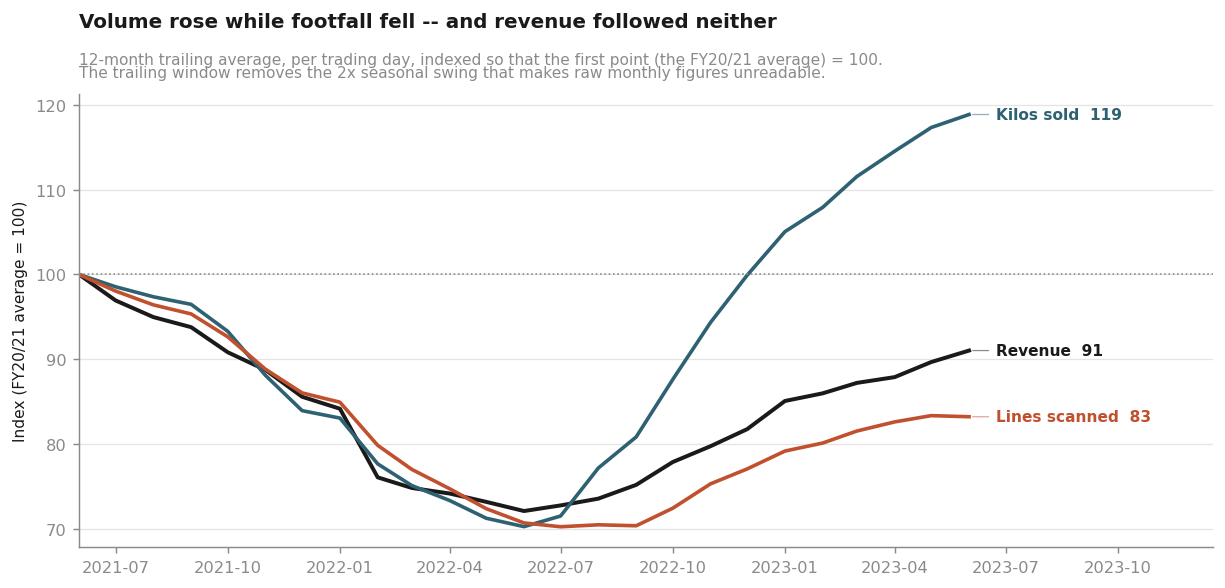

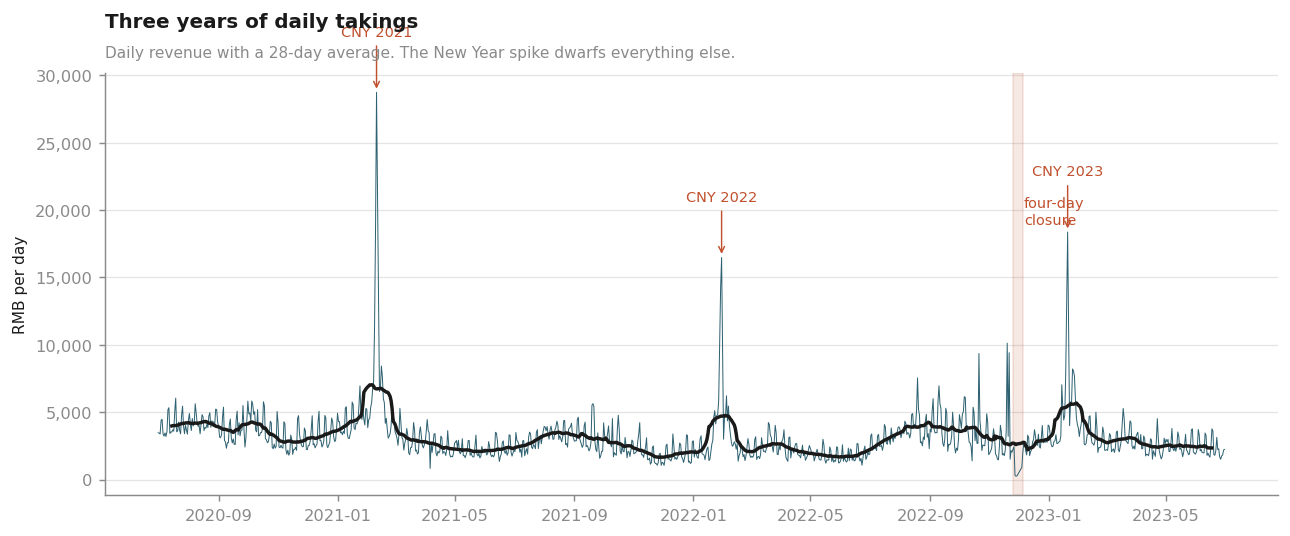

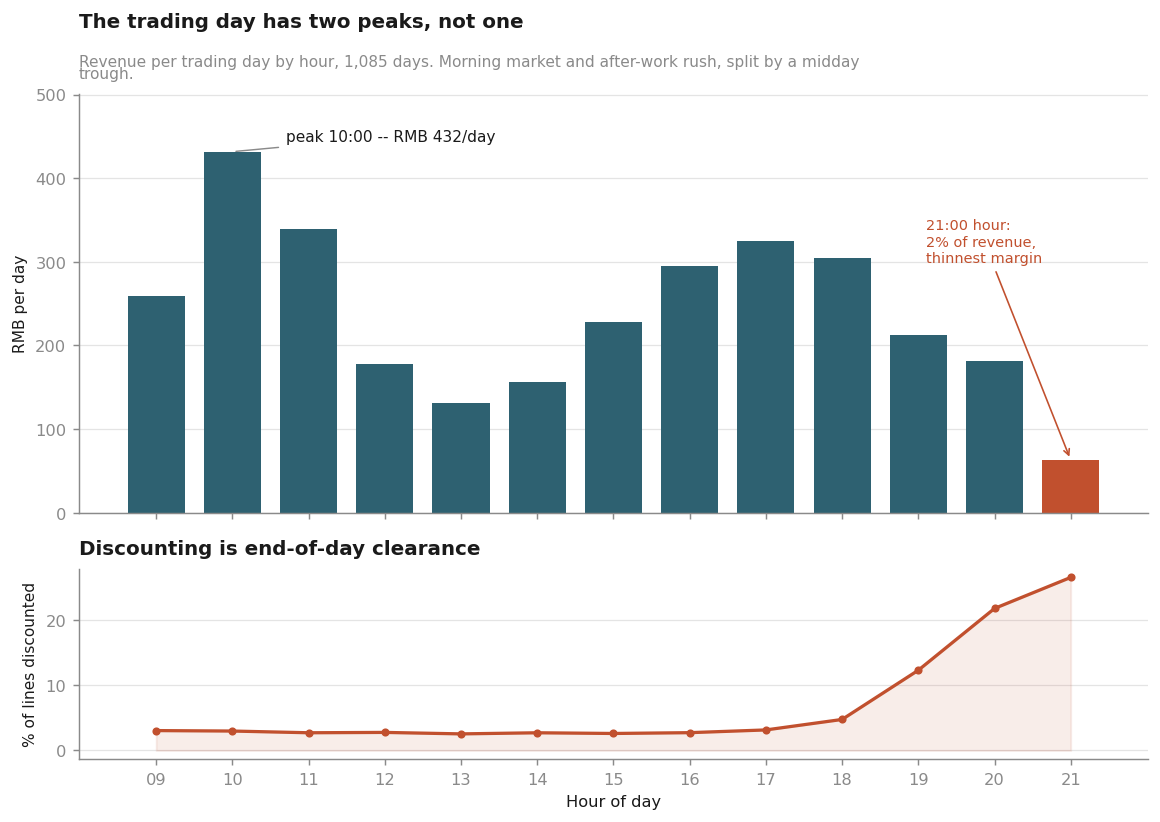

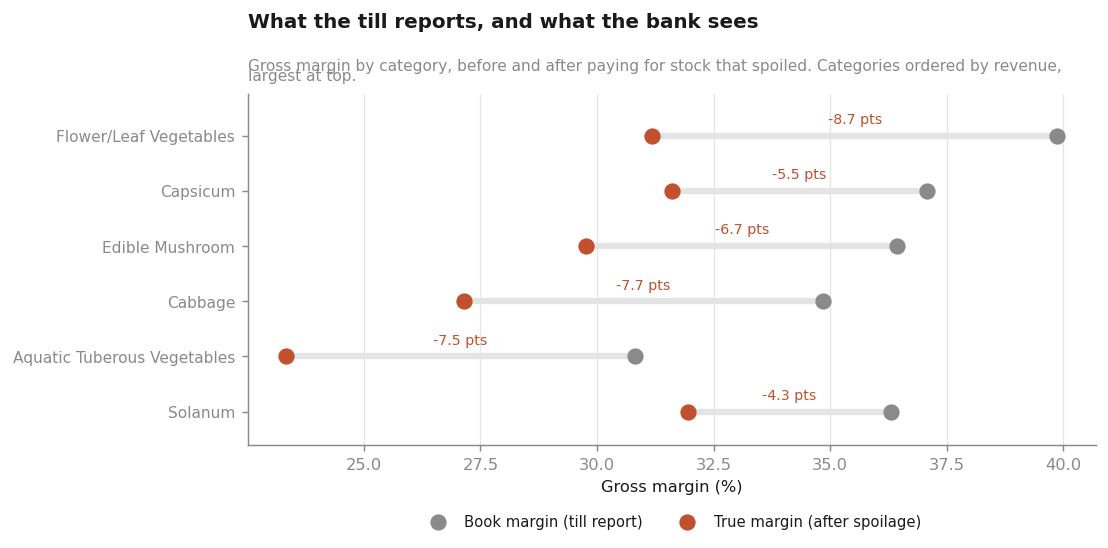

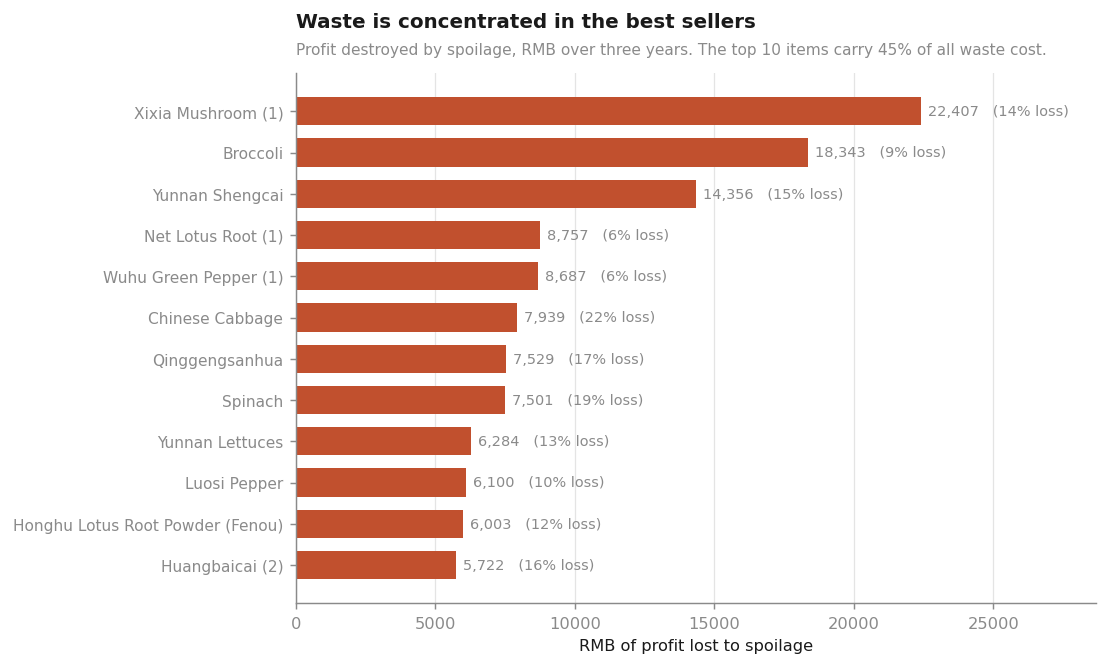

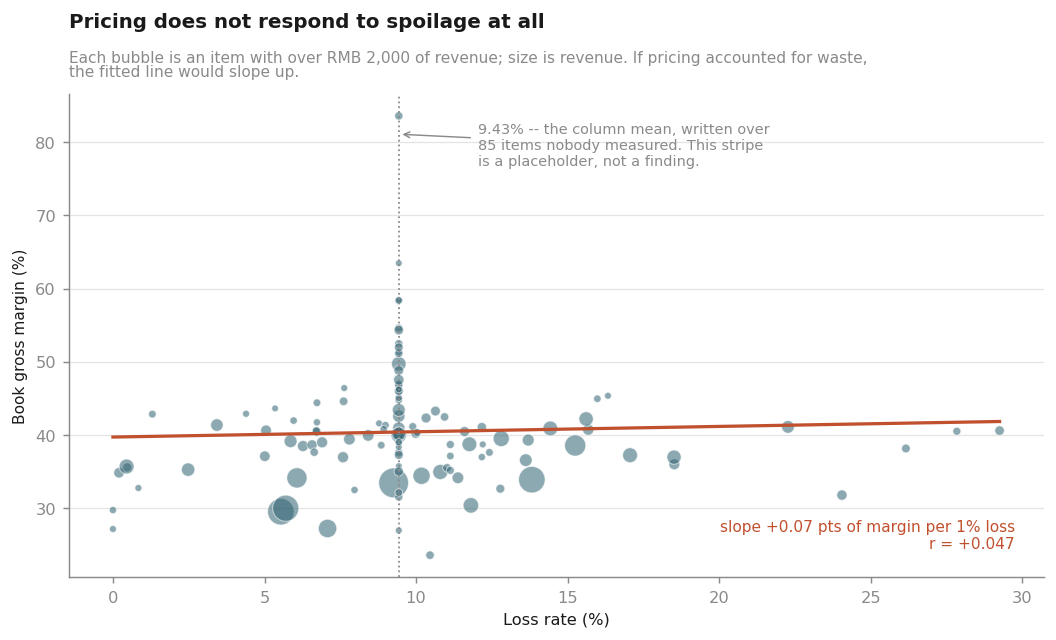

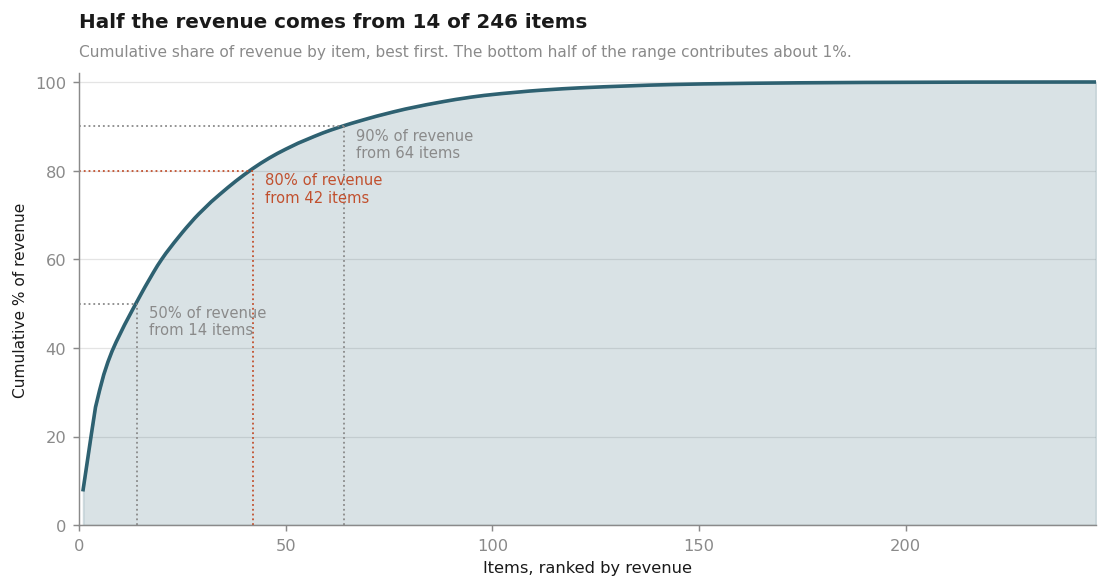

In [30]:
from IPython.display import Image, display
for f in ['volume_vs_footfall_trend.png',
          'daily_revenue_three_years.png',
          'hourly_revenue_and_discounting.png',
          'category_margin_gap.png',
          'spoilage_cost_by_item.png',
          'loss_rate_vs_margin.png',
          'revenue_concentration.png']:
    display(Image(filename=f'../figures/{f}'))

## 10. Conclusions

**What went wrong**

1. **Footfall is draining while volume grows.** Lines per day fell 17% as kilos
   rose 19%. Revenue held up on bigger baskets and cheaper produce, which is a
   position that works right up until it does not — and no revenue-only report
   would show it.
2. **Spoilage is not priced in, anywhere.** RMB 239,699 of reported profit never
   existed. The correlation between an item's loss rate and its markup is +0.05 —
   indistinguishable from zero at any revenue threshold.
3. **Waste concentrates in the best sellers.** The top 10 items carry 44% of all
   spoilage cost, because waste is loss rate times volume.
4. **The range is duplicated, not just long.** 246 item codes represent only 167
   distinct products — 7 separate barcodes for Haixian Mushroom alone. Separately,
   60 items sold on ten days or fewer and 110 have not sold at all in the final
   six months.
5. **The last trading hour does not pay for itself.** 2% of revenue at the
   thinnest margin and the heaviest discounting of the day.

**What to do**

| Action | Why it is the right size of fix |
|---|---|
| Price from `cost / (1 - loss_rate)` | One formula; recovers the single largest leak in the data |
| Attack the top 10 waste items specifically | 44% of waste cost sits in a list short enough to act on this week |
| Put lines/day on the revenue chart | The erosion is invisible on revenue alone |
| Consolidate duplicate SKUs first | 246 codes are only 167 products; merging costs the customer nothing |
| Quarterly range review, 90-day delist rule | Returns ordering attention to the lines that are volume-constrained |
| Split the delivery: heavy pre-09:00, light pre-16:00 | Fixes what feeds the evening clearance pile, rather than the markdown itself |
| Close at 21:00, move the hour to 09:00–11:00 | A roster change, not an investment |

**Where this stops.** Worth being explicit, because the limits bound every
recommendation above:

* One produce counter, not a shop — vegetables and mushrooms only, so nothing here
  describes the rest of the store.
* No basket or customer ID — nothing here counts shoppers or measures basket size.
* No stock-on-hand — spoilage is a per-item rate, not an observed daily loss, and
  85 of those rates are placeholders.
* Stockouts are invisible — *no demand* and *no stock* look identical.
* Everything below gross margin is absent. Rent, wages, power and transport are
  not in these files, so nothing here says whether the business is profitable —
  only which lines and hours contribute most to covering costs it cannot see.